In [101]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing,make_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

from tqdm import tqdm
from math import isclose

# globals

random_seed = 42       

In [102]:
# The polynomials

def f(x,degree):
    if degree==2:
        return 0.125*x**2 - 0.95*x + 1.925 
    elif degree==3:
        return 0.125*x**3 - 1.2*x**2 + 3*x + 0.5   
    elif degree==4:
        return 0.41*x**4 - 5.99*x**3 + 30.55*x**2 - 62.37*x + 41.4
    elif degree==5:
        return  -0.4*x**5 + 7.0*x**4 - 46.17*x**3 + 142.0*x**2 - 200.43*x + 102.0 
    elif degree==6:
        return -0.5219*x**6 + 10.7724*x**5 - 87.6206*x**4 + 355.7914*x**3 - 751.5246*x**2 + 774.0203*x - 300.917
    else:
        print("Degree must be in range [2..6]")
        return None
            
def make_poly_model(n_samples=10, degree=4,noise=1.0, show_data=False, show_model=True,random_state=random_seed):
    
    lb,ub = 1,6
            
    X_all = np.linspace(lb,ub,1000)
    y_perfect_model = f(X_all,degree)

    np.random.seed(random_state)
    X = np.linspace(lb,ub,n_samples)             # evenly spaced samples for simplicity
    y = f(X,degree) + np.random.normal(0, noise,size=n_samples)

    # Plotting the scatter plot of the data 

    if show_data:
      
        plt.figure(figsize=(8, 5))
        plt.scatter(X, y, marker='.',label=f'{n_samples} Data Points; Noise std = {noise}')
        if show_model:
            plt.plot(X_all, y_perfect_model, label='Underlying Model without noise', linestyle='--',color='grey', alpha=0.5)
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'Degree {degree} Polynomial Noisy Dataset')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    return X.reshape(-1,1),y

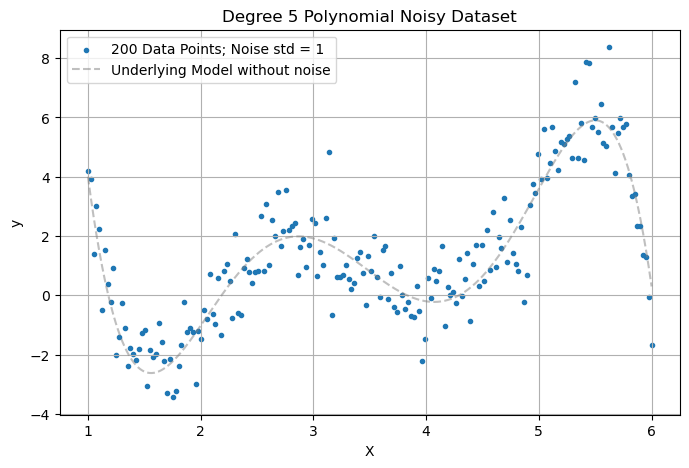

In [103]:
# Play around with various values here just to see what it does
# Make sure you see that the plot will change the scale as the data changes -- always watch the y-axis scale!

X,y = make_poly_model(n_samples=200,
                      degree=5,               # try values in the range 2 .. 6. 
                      noise=1,             # try values in the range 0 .. 10 and make sure to try values < 1. 
                      show_data=True,
                      random_state=None
                     )

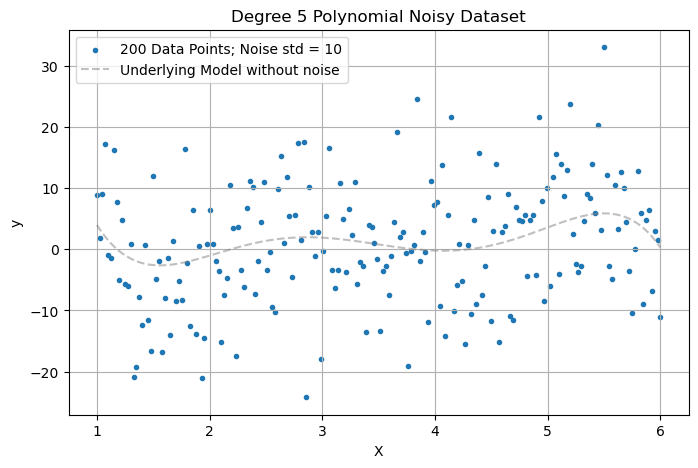

In [104]:
# Your code here
n_samples = 200
degree = 5
noise = 10
random_state = random_seed

X, y = make_poly_model(n_samples=n_samples,
                      degree=degree,
                      noise=noise,
                      show_data=True,
                      random_state=random_state)

# Split the data into training and evaluation sets
test_size = 0.3
random_state = random_seed

X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=test_size, random_state=random_state)



In [105]:
# Sample size of training and evaluation sets
print(X_train.shape[0], X_eval.shape[0], y_train.shape, y_eval.shape)

140 60 (140,) (60,)


<Figure size 1400x500 with 0 Axes>

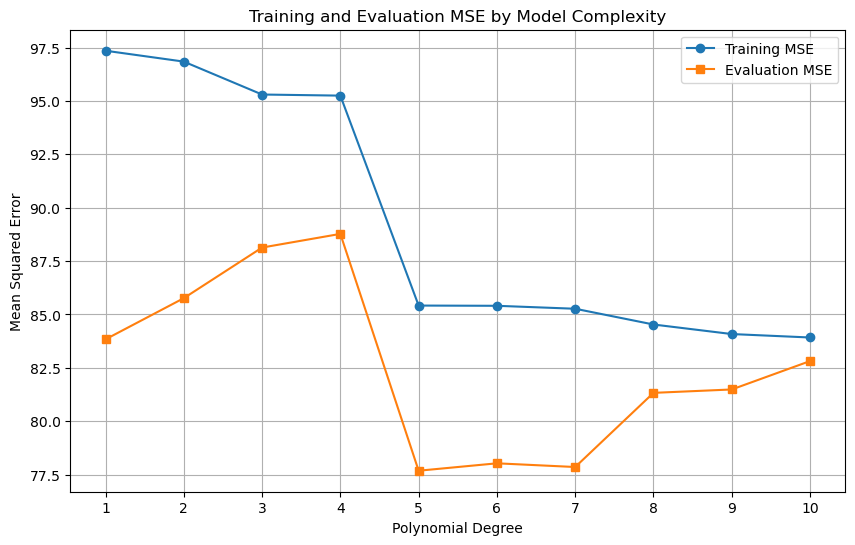

Minimum Evaluation MSE: 77.6807
Best Model Degree: 5


In [106]:
# Template for Problem One Part C

degrees = range(1,11) # try polynomials of these degrees
train_errors = []     # store training MSEs for each degree here
evaluation_errors  = []     # store evaluation MSEs for each degree here

plt.figure(figsize=(14, 5))
for d in degrees:

    # pass             # remove: just to get the cell to run without error

    # Use PolynomialFeatures to transform the data into appropriate form for
    # a polynomial model of degree d.
    # ax = plt.subplot(1, len(degrees), d + 1)
    #plt.setp(ax, xticks=(), yticks=())
    polynomial_features = PolynomialFeatures(degree=d, include_bias=False)

    # Fit a linear regression model on the transformed data

    model = LinearRegression()
    X_train_poly = polynomial_features.fit_transform(X_train)
    X_eval_poly = polynomial_features.transform(X_eval)
    model.fit(X_train_poly, y_train)

    # Predict on the train and evaluation sets

    y_train_pred = model.predict(X_train_poly)
    y_eval_pred = model.predict(X_eval_poly)

    # Calculate the MSEs and append to the appropriate lists

    train_mse = mean_squared_error(y_train, y_train_pred)
    eval_mse = mean_squared_error(y_eval, y_eval_pred)

    train_errors.append(train_mse)
    evaluation_errors.append(eval_mse)
    

    
# Plot training and evaluation MSEs vs degree of model using train_errors and evaluation_errors
# Note that the x axis should have ticks for 1 .. 10 only

# Your code here
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', label="Training MSE")
plt.plot(degrees, evaluation_errors, 's-', label="Evaluation MSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training and Evaluation MSE by Model Complexity")
plt.legend()    
plt.grid(True)
plt.xticks(degrees)
plt.show()
# Calculate and print out the minimal MSE for evaluation set and degree where it was obtained 
# Hint: notice carefully that the MSE lists are for degrees [1, 2, 3, ....]  (i.e., index + 1)

# Your code here
min_eval_mse = min(evaluation_errors)
best_degree = evaluation_errors.index(min_eval_mse) + 1
print(f"Minimum Evaluation MSE: {min_eval_mse:.4f}")
print(f"Best Model Degree: {best_degree}")


/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_11951/3429132977.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


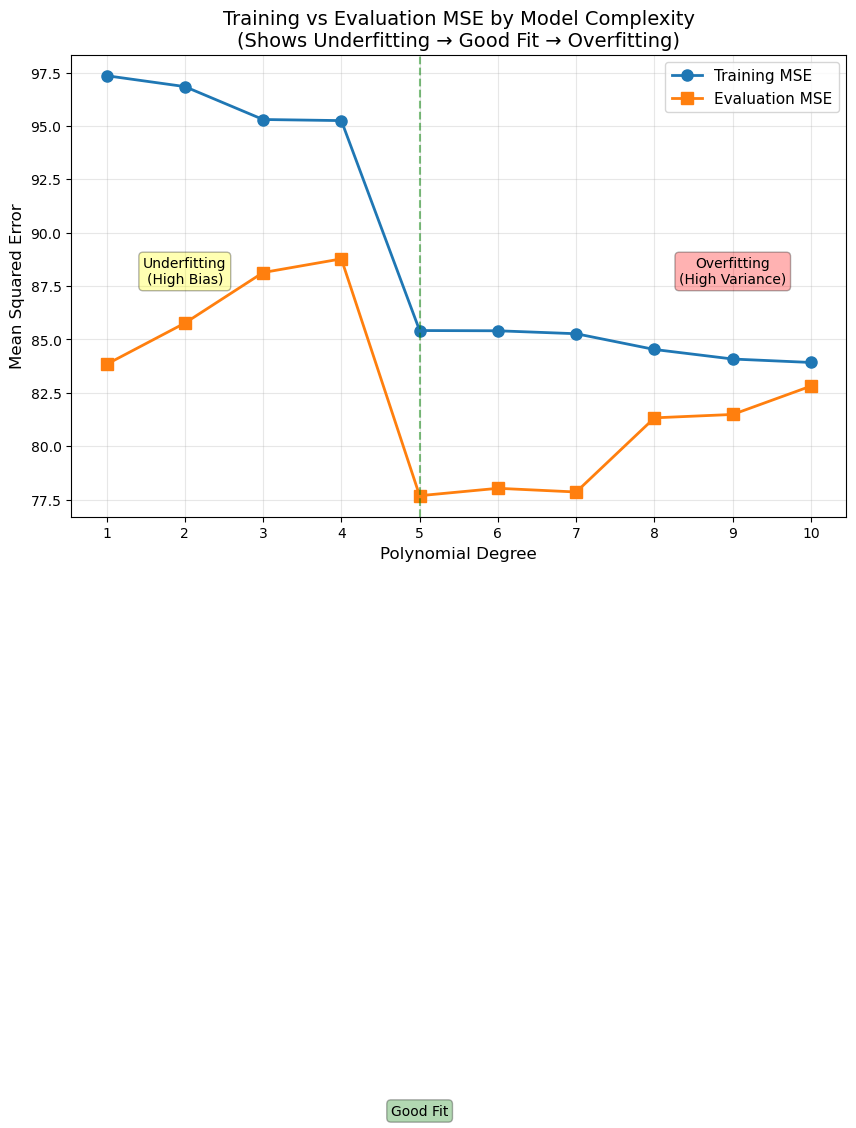


Best Model: Degree 5 with Evaluation MSE = 77.6807


In [107]:
degrees = range(1, 11)
train_errors = []
evaluation_errors = []

# First, collect all the errors
for d in degrees:
    polynomial_features = PolynomialFeatures(degree=d, include_bias=False)
    model = LinearRegression()
    
    X_train_poly = polynomial_features.fit_transform(X_train)
    X_eval_poly = polynomial_features.transform(X_eval)
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_eval_pred = model.predict(X_eval_poly)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    eval_mse = mean_squared_error(y_eval, y_eval_pred)
    
    train_errors.append(train_mse)
    evaluation_errors.append(eval_mse)

# Now create the main plot showing error vs degree
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', label='Training MSE', linewidth=2, markersize=8)
plt.plot(degrees, evaluation_errors, 's-', label='Evaluation MSE', linewidth=2, markersize=8)

plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Training vs Evaluation MSE by Model Complexity\n(Shows Underfitting → Good Fit → Overfitting)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(degrees)

# Add annotations to show the phases
min_eval_idx = evaluation_errors.index(min(evaluation_errors))
plt.axvline(x=list(degrees)[min_eval_idx], color='green', linestyle='--', alpha=0.5, label=f'Best Model (Degree {list(degrees)[min_eval_idx]})')

# Optional: Add text annotations
plt.text(2, max(train_errors)*0.9, 'Underfitting\n(High Bias)', ha='center', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
plt.text(list(degrees)[min_eval_idx], max(train_errors)*0.5, 'Good Fit', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))
plt.text(9, max(train_errors)*0.9, 'Overfitting\n(High Variance)', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

plt.tight_layout()
plt.show()

# Print the minimum evaluation MSE
min_eval_mse = min(evaluation_errors)
best_degree = list(degrees)[evaluation_errors.index(min_eval_mse)]
print(f"\nBest Model: Degree {best_degree} with Evaluation MSE = {min_eval_mse:.4f}")

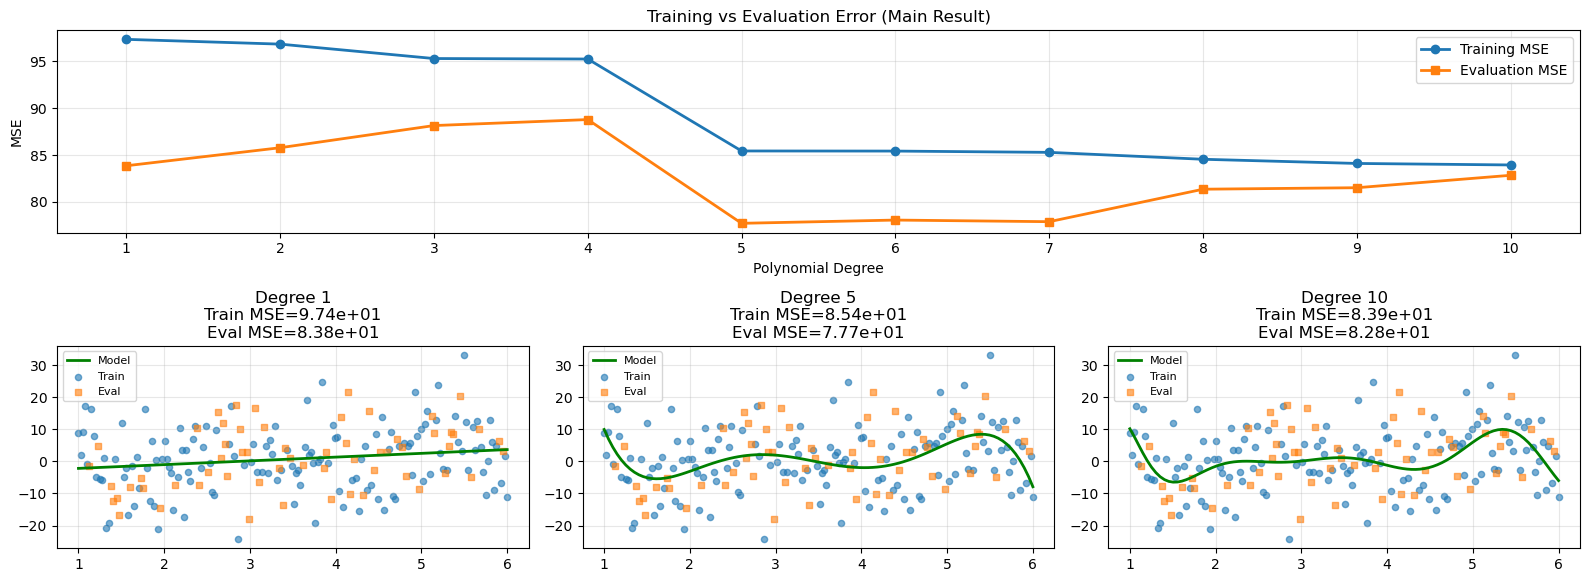

In [108]:
# Create a figure with subplots
fig = plt.figure(figsize=(16, 12))

# Top plot: Error curves (takes full width)
ax1 = plt.subplot(4, 1, 1)
ax1.plot(degrees, train_errors, 'o-', label='Training MSE', linewidth=2)
ax1.plot(degrees, evaluation_errors, 's-', label='Evaluation MSE', linewidth=2)
ax1.set_xlabel('Polynomial Degree')
ax1.set_ylabel('MSE')
ax1.set_title('Training vs Evaluation Error (Main Result)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(degrees)

# Bottom plots: Show fits for selected degrees (3, 5, 10)
selected_degrees = [1, 5, 10]  # underfitting, good fit, overfitting
for i, d in enumerate(selected_degrees):
    ax = plt.subplot(4, 3, 4 + i)
    
    # Refit the model
    polynomial_features = PolynomialFeatures(degree=d, include_bias=False)
    model = LinearRegression()
    X_train_poly = polynomial_features.fit_transform(X_train)
    model.fit(X_train_poly, y_train)
    
    # Create smooth prediction line
    X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_test_poly = polynomial_features.transform(X_test)
    
    ax.plot(X_test, model.predict(X_test_poly), 'g-', label="Model", linewidth=2)
    ax.scatter(X_train, y_train, s=20, alpha=0.6, label="Train")
    ax.scatter(X_eval, y_eval, s=20, alpha=0.6, marker='s', label="Eval")
    
    idx = list(degrees).index(d)
    ax.set_title(f"Degree {d}\nTrain MSE={train_errors[idx]:.2e}\nEval MSE={evaluation_errors[idx]:.2e}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

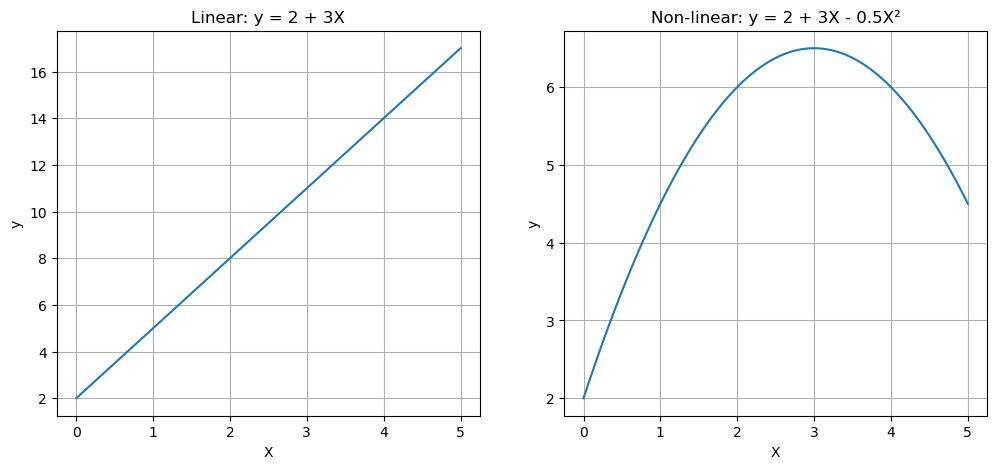

In [109]:
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(0, 5, 100)

# Linear relationship
y_linear = 2 + 3*X

# Non-linear relationship (using X²)
y_nonlinear = 2 + 3*X - 0.5*X**2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(X, y_linear)
plt.title('Linear: y = 2 + 3X')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(X, y_nonlinear)
plt.title('Non-linear: y = 2 + 3X - 0.5X²')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)

plt.show()

In [110]:
# Load the dataset
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg','cylinders','displacement','horsepower','weight',
                'acceleration','model_year','origin','car_name']
# df = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values='?')
df_mpg = pd.read_csv(url, sep=r'\s+', names=column_names, na_values='?')

In [111]:
# Your code here -- add additional cells if you wish
# drop the car_name column without modifying the original df_mpg
df_mpg_cleaned = df_mpg.copy().drop(columns=['car_name'])

# drop the rows where the horsepower value is missing
df_mpg_cleaned = df_mpg_cleaned.dropna(subset=['horsepower'])
df_mpg_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 27.6 KB


Training RMSE: 3.3135
Evaluation RMSE: 3.2727
Training MAE: 2.5482
Evaluation MAE: 2.4198


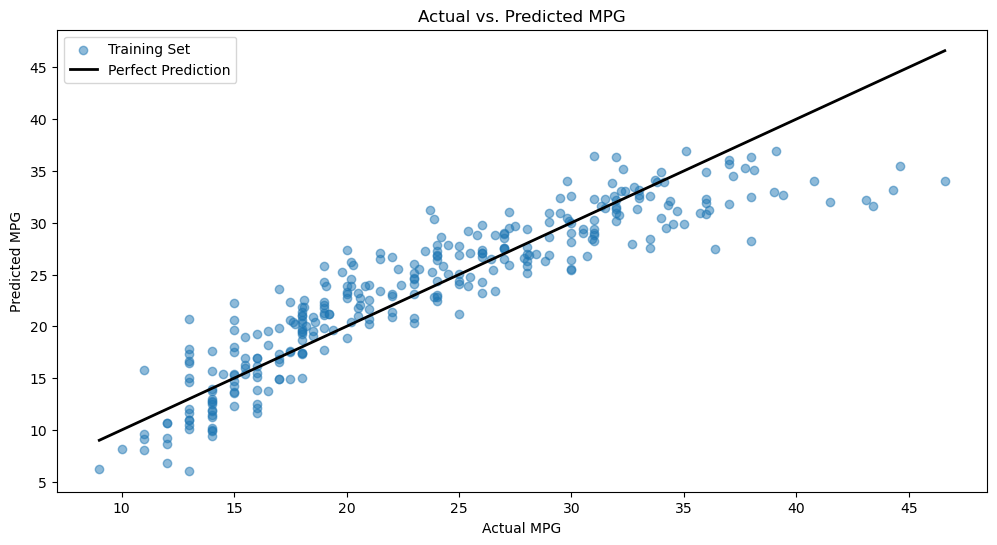

In [112]:
# Your code here; add as many cells as you need
mpg_y = df_mpg_cleaned['mpg']
mpg_x = df_mpg_cleaned.drop(columns=['mpg'])

# split the data into training and evaluation sets
X_train, X_eval, y_train, y_eval = train_test_split(mpg_x, mpg_y, test_size=0.2, random_state=random_seed)

# fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# predict the training and evaluation sets
y_train_pred = model.predict(X_train)
y_eval_pred = model.predict(X_eval)

# compute the RMSE and MAE for the training and evaluation sets
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
eval_rmse = np.sqrt(mean_squared_error(y_eval, y_eval_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
eval_mae = mean_absolute_error(y_eval, y_eval_pred)

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Evaluation RMSE: {eval_rmse:.4f}")
print(f"Training MAE: {train_mae:.4f}")
print(f"Evaluation MAE: {eval_mae:.4f}")

# visualize the training results
plt.figure(figsize=(12, 6))
plt.scatter(y_train, y_train_pred, label='Training Set', alpha=0.5)
# plt.scatter(y_eval, y_eval_pred, label='Evaluation Set', alpha=0.5)
plt.plot([min(y_train.min(), y_eval.min()), max(y_train.max(), y_eval.max())],
         [min(y_train.min(), y_eval.min()), max(y_train.max(), y_eval.max())],
         color='black', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs. Predicted MPG')
plt.legend()
plt.show()



In [114]:
# General rule of thumb for choosing transformation

# Check skewness
from scipy.stats import skew

hp_skewness = skew(df_mpg_cleaned['horsepower'])
weight_skewness = skew(df_mpg_cleaned['weight'])

print(f"Horsepower skewness: {hp_skewness:.2f}")
print(f"Weight skewness: {weight_skewness:.2f}")

# Skewness guidelines:
# 0.0 to 0.5: Nearly symmetric → No transform needed
# 0.5 to 1.0: Moderate skew → Try square root (√x)
# 1.0+: Heavy skew → Try log(x)
# 2.0+: Severe skew → Try log(x) or 1/x

Horsepower skewness: 1.08
Weight skewness: 0.52


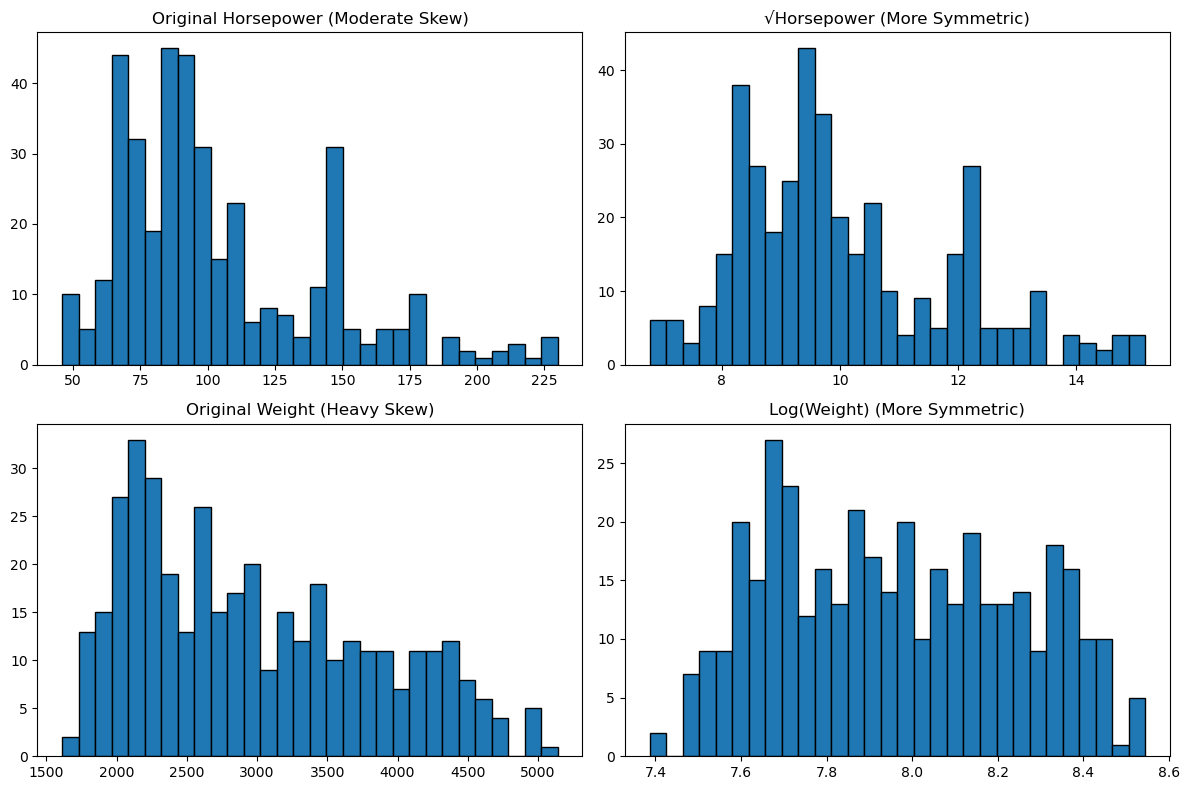

In [115]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original horsepower
axes[0, 0].hist(df_mpg_cleaned['horsepower'], bins=30, edgecolor='black')
axes[0, 0].set_title('Original Horsepower (Moderate Skew)')

# Transformed horsepower
axes[0, 1].hist(np.sqrt(df_mpg_cleaned['horsepower']), bins=30, edgecolor='black')
axes[0, 1].set_title('√Horsepower (More Symmetric)')

# Original weight
axes[1, 0].hist(df_mpg_cleaned['weight'], bins=30, edgecolor='black')
axes[1, 0].set_title('Original Weight (Heavy Skew)')

# Transformed weight
axes[1, 1].hist(np.log1p(df_mpg_cleaned['weight']), bins=30, edgecolor='black')
axes[1, 1].set_title('Log(Weight) (More Symmetric)')

plt.tight_layout()
plt.show()

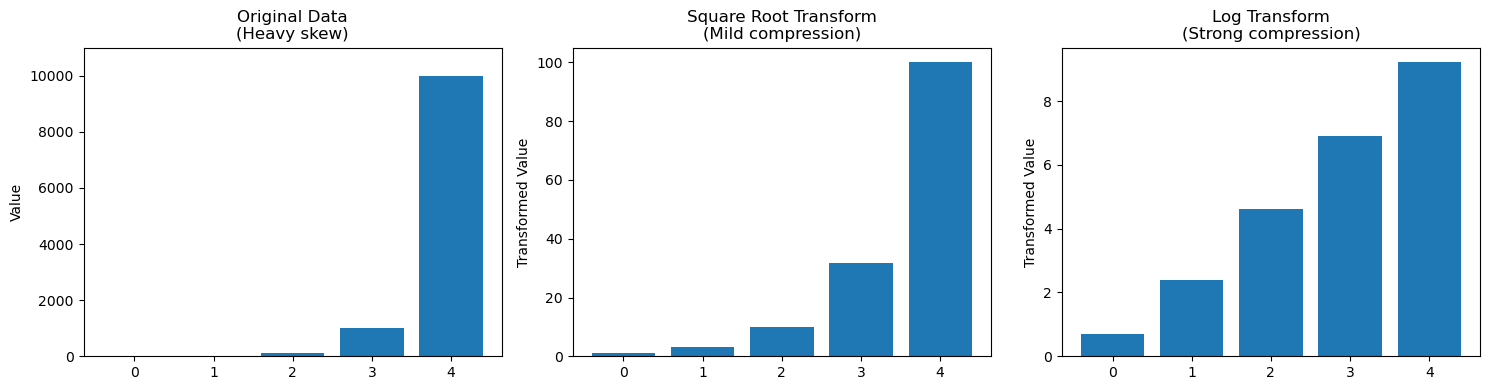

Original:    [    1    10   100  1000 10000]
Square Root: [  1.     3.16  10.    31.62 100.  ]
Log:         [0.69 2.4  4.62 6.91 9.21]


In [116]:
import numpy as np
import matplotlib.pyplot as plt

# Sample skewed data
x = np.array([1, 10, 100, 1000, 10000])

# Different transformations
identity = x
sqrt_transform = np.sqrt(x)
log_transform = np.log1p(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original data
axes[0].bar(range(len(x)), x)
axes[0].set_title('Original Data\n(Heavy skew)')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0, 11000)

# Square root
axes[1].bar(range(len(x)), sqrt_transform)
axes[1].set_title('Square Root Transform\n(Mild compression)')
axes[1].set_ylabel('Transformed Value')

# Log transform
axes[2].bar(range(len(x)), log_transform)
axes[2].set_title('Log Transform\n(Strong compression)')
axes[2].set_ylabel('Transformed Value')

plt.tight_layout()
plt.show()

print("Original:   ", x)
print("Square Root:", sqrt_transform.round(2))
print("Log:        ", log_transform.round(2))

# Why Different Transformations for Horsepower vs Weight

## Quick Summary Table

| Variable | Skewness Level | Transformation | Reason |
|----------|----------------|----------------|---------|
| **Horsepower** | Moderate | `√x` (Square Root) | Mild compression, preserves relative differences |
| **Weight** | Heavy | `log(1+x)` (Logarithm) | Strong compression for data spanning wide range |

## Transformation Strength Ranking

From weakest to strongest compression:

1. **Identity**: `x` - No transformation
2. **Square root**: `√x` - Mild compression (for moderate skew)
3. **Cube root**: `∛x` - Moderate compression
4. **Logarithm**: `log(x)` - Strong compression (for heavy skew)
5. **Reciprocal**: `1/x` - Very strong compression

## Skewness Guidelines for Choosing Transformations

| Skewness Value | Description | Recommended Transformation |
|----------------|-------------|---------------------------|
| 0.0 to 0.5 | Nearly symmetric | No transform needed |
| 0.5 to 1.0 | Moderate skew | Square root `√x` |
| 1.0 to 2.0 | Heavy skew | Logarithm `log(x)` |
| 2.0+ | Severe skew | Logarithm `log(x)` or reciprocal `1/x` |

## Key Principle

**Match the transformation strength to the skewness severity!**

- Moderate skew → Mild transformation (square root)
- Heavy skew → Strong transformation (logarithm)